2026-02-05 08:05:39.916242: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-05 08:05:39.945666: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX512F AVX512_VNNI, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Found 1650 files belonging to 2 classes.
Using 1320 files for training.
Found 1650 files belonging to 2 classes.
Using 330 files for validation.
Index(['filepath', 'label'], dtype='object')


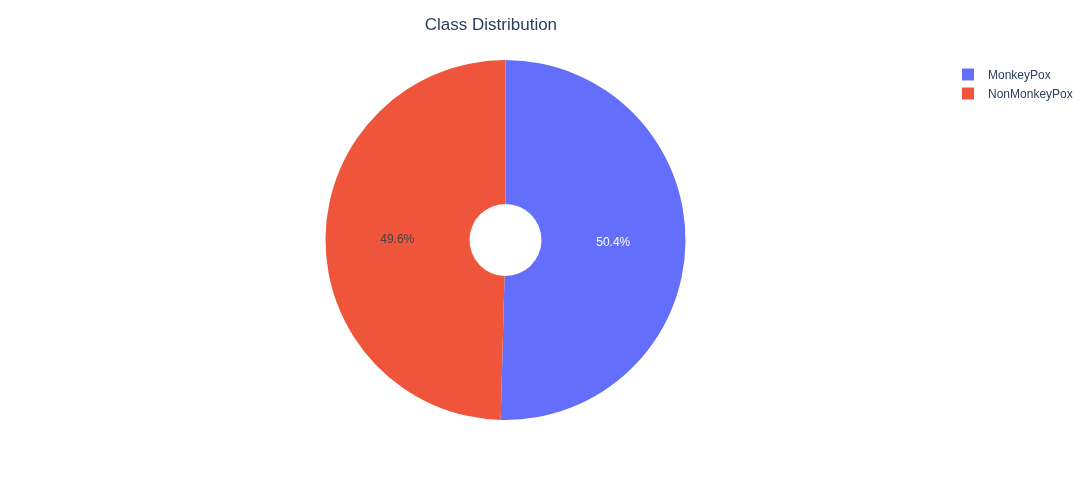

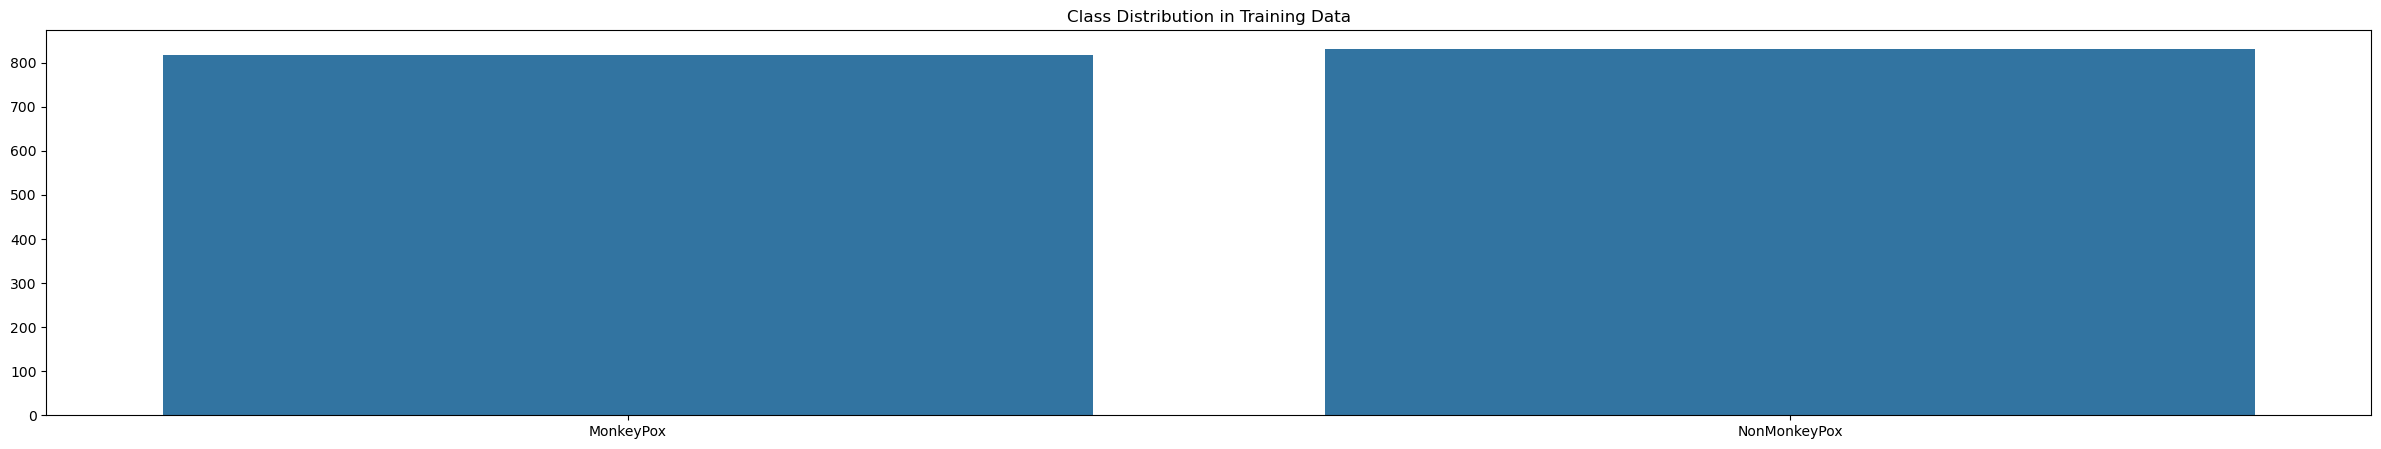

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 5, 5, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_94          │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_95          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,863,138 (87.22 MB)

 Trainable params: 6,211,266 (23.69 MB)

 Non-trainable params: 16,651,872 (63.52 MB)

Epoch 1/40
42/42 ━━━━━━━━━━━━━━━━━━━━ 47s 999ms/step - accuracy: 0.7227 - loss: 0.9215 - val_accuracy: 0.5212 - val_loss: 4.2665 - learning_rate: 9.0000e-04
Epoch 2/40
42/42 ━━━━━━━━━━━━━━━━━━━━ 41s 981ms/step - accuracy: 0.8220 - loss: 0.4838 - val_accuracy: 0.5394 - val_loss: 3.3600 - learning_rate: 9.0000e-04
Epoch 3/40
42/42 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.8364 - loss: 0.4440 - val_accuracy: 0.5848 - val_loss: 1.3826 - learning_rate: 9.0000e-04
Epoch 4/40
42/42 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.8720 - loss: 0.3248 - val_accuracy: 0.7515 - val_loss: 0.5785 - learning_rate: 9.0000e-04
Epoch 5/40
42/42 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.9197 - loss: 0.2313 - val_accuracy: 0.7030 - val_loss: 0.9656 - learning_rate: 9.0000e-04
Epoch 6/40
42/42 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.9174 - loss: 0.2058 - val_accuracy: 0.8758 - val_loss: 0.3375 - learning_rate: 9.0000e-04
Epoch 7/40
42/42 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.9417 -

In [1]:
# Required Libraries
import numpy as np
import pandas as pd
import os
import glob as gb
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf
from tensorflow import keras
from keras import layers
from keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D, BatchNormalization
from keras.models import Sequential
from keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau
import plotly.express as px

# Define image dimensions and batch size
image_height = 224
image_width = 224  # Fixed typo from 'image_weight'
batch_size = 16  # Standardized to 16 based on the code

# Specify the path to your dataset
tpath = 'aug'  # Update this with your local path if needed

# Load the training and validation data using image_dataset_from_directory
training_data = tf.keras.utils.image_dataset_from_directory(
    tpath,
    batch_size=32,  # As in the provided code
    image_size=(image_height, image_width),
    shuffle=True,
    seed=123,
    validation_split=0.2,
    subset='training'
)

validation_data = tf.keras.utils.image_dataset_from_directory(
    tpath,
    batch_size=batch_size,
    image_size=(image_height, image_width),
    shuffle=True,
    seed=123,
    validation_split=0.2,
    subset='validation'
)

# Load the metadata information (Update the path if needed)
info_file = 'labels_aug.csv'  # Update the path
info = pd.read_csv(info_file)
info.head()

# Check the column names
print(info.columns)

# Corrected pie chart to use 'label' column (assuming it's lowercase based on your code)
fig = px.pie(
    names=info['label'].unique(),
    values=info['label'].value_counts(),
    hole=0.2,
    width=500,
    height=500
)
fig.update_layout({'title': {'text': 'Class Distribution', 'x': 0.45}})
fig.show()

# Visualize class distribution in a bar plot
class_names = []
class_count = []
train_examples = 0

for f in os.listdir(tpath):
    files = gb.glob(pathname=str(tpath + "//" + f + "/*"))
    class_names.append(f)
    class_count.append(len(files))
    train_examples += len(files)

plt.figure(figsize=(30, 5))
sns.barplot(x=class_names, y=class_count)
plt.title("Class Distribution in Training Data")
plt.show()

# Optional: If you have an existing .h5 model and just want to convert to .keras without retraining
# Uncomment and run this section if applicable
# existing_model_path = 'inceptionV3.h5'  # Path to your pretrained .h5 file
# model = keras.models.load_model(existing_model_path)
# model.save('inceptionV3_converted.keras')  # Save in .keras format
# print("Model converted and saved as .keras")

# Build the InceptionV3 model with transfer learning (main training section)
InceptionV3_model = Sequential()

# Load the pre-trained InceptionV3 model without the top layers
pretrained_model = keras.applications.InceptionV3(
    include_top=False,
    input_shape=(image_height, image_width, 3),
    pooling=None,
    weights='imagenet'
)

# Fine-tune the last few layers of the pre-trained model
for layer in pretrained_model.layers[:-30]:  # Freeze all layers except the last 30
    layer.trainable = False

# Add the pre-trained InceptionV3 to the Sequential model
InceptionV3_model.add(pretrained_model)

# Add Global Average Pooling
InceptionV3_model.add(GlobalAveragePooling2D())

# Add Batch Normalization for stabilization and faster training
InceptionV3_model.add(BatchNormalization())

# Add Dropout for regularization
InceptionV3_model.add(Dropout(0.5))

# Add custom dense layers
InceptionV3_model.add(Dense(512, activation='relu'))

# Add Batch Normalization after the Dense layer
InceptionV3_model.add(BatchNormalization())

# Add another Dropout layer for regularization
InceptionV3_model.add(Dropout(0.5))

# Output layer for binary classification (assuming 2 classes)
InceptionV3_model.add(Dense(2, activation='softmax'))

InceptionV3_model.summary()

# Compile the model with Adam optimizer
InceptionV3_model.compile(
    optimizer=Adam(learning_rate=0.0009),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Introduce learning rate reduction on plateau
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=0.00001, verbose=1)

# Train the model
epochs = 40
history_inception = InceptionV3_model.fit(
    training_data,
    validation_data=validation_data,
    epochs=epochs,
    callbacks=[reduce_lr],
    verbose=1
)

# Save the trained model in .keras format
InceptionV3_model.save('inceptionV3.keras')
print("Model trained and saved as inceptionV3.keras")

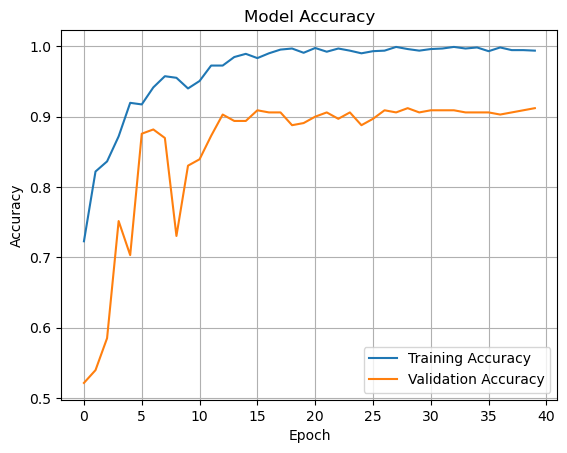

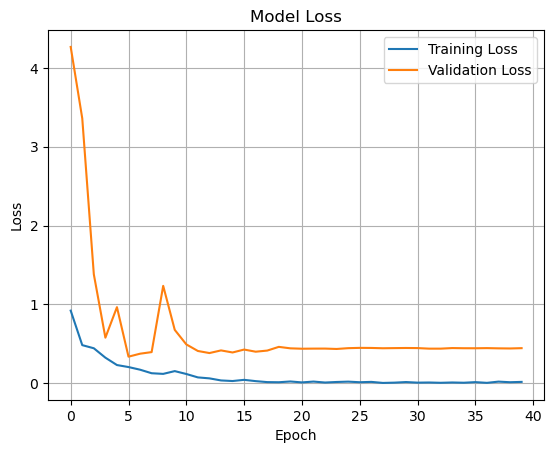

In [2]:
# Visualize training and validation accuracy
import matplotlib.pyplot as plt

plt.plot(history_inception.history['accuracy'], label='Training Accuracy')
plt.plot(history_inception.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Visualize training and validation loss
plt.plot(history_inception.history['loss'], label='Training Loss')
plt.plot(history_inception.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()